# Utilization

In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import copy
import sys
sys.path.insert(0, "../src/")
from Neurons import *
from Network import *
from inputFuc import *
from utils import *
from plotting import *

# Compare learning

## Teacher-student in Multi-layer

tensor([ 4, 12])
reach steady state with error: 0.000198


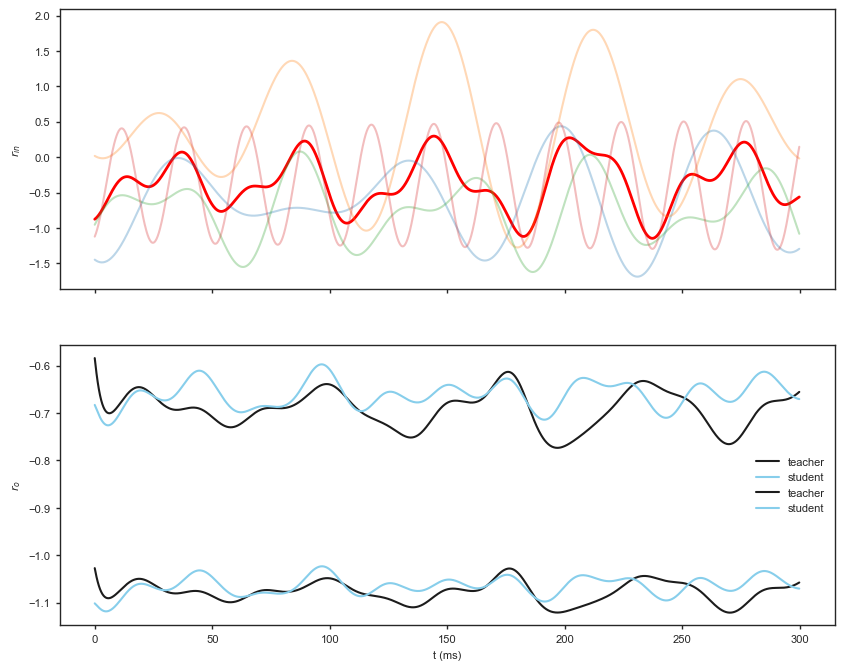

In [5]:
#### With P learning ###
dt = 0.25 #ms

init_phase = 300 #ms
init_phase_steps = int(init_phase/dt) 
learn_phase = 50000 # ms
learn_phase_steps = int(learn_phase/dt) 
eval_phase = 200 # ms
eval_phase_steps = int(eval_phase/dt)

# init both teacher and student net
n_in, n_hidden1, n_hidden2, n_out = 4, 3, 2, 2
beta=0.5
activation='sigmoid'

student = DEFwdNetwork(
    layers=[
        FwdDENeurons(n_in=n_in, n_neurons=n_hidden1, tau=[1.7, 3., 7.], lr_w=0.1,
                     activation=activation, dt=dt, scale=1.0),
        LastFwdDENeurons(n_in=n_hidden1, n_neurons=n_hidden2, tau=[4, 12], lr_w=0.1,
                     activation=activation, dt=dt, scale=1.0),
        FwdNeurons(n_in=n_hidden2, n_neurons=n_out, tau=dt, 
                   lr_w=0.0, activation='linear', dt=dt)
    ],
    beta=beta
)

# n_in, n_hidden1, n_out = 3, 2, 1
# student = FwdNetwork(
#     layers=[
#         FwdEPNeurons(n_in=n_in, n_neurons=n_hidden1, tau=[13, 67], lr_w=1.5,
#                      activation=activation, dt=dt, scale=1.6),
#         FwdNeurons(n_in=n_hidden1, n_neurons=n_out, tau=dt, 
#                    lr_w=0.0, activation='linear', dt=dt, beta=beta)
#     ],)


#student2 = FwdNetwork(net=student, layers=FwdRFNeurons)

student3 = FwdNetwork(net=student, layers=FwdGLENeurons)
student2 = RTRLNetwork(net=student)
student_naive = copy.deepcopy(student2)
teacher = copy.deepcopy(student2)
student.reset()
student2.reset()
student3.reset()
#student.beta *= 2

Students={'DeepElig':student, 'Eprop':student2, 'GLE':student3, 'naive':student_naive}



# deviate teacher by small perturbation
with torch.no_grad():
    for i, l in enumerate(student.layers[:-1]):
        deviate = torch.randn(l.W_in.shape)*6e-1
        teacher.layers[i].W_in += deviate

input_fuc = mul_sin_function(n=n_in, n_sin=2, period=(20, 80), bias = (-0.5, 0.5), magnitude=(0.2, 1), phase = (0, 6), dt=dt)
#input_fuc = mul_sin_function(n=n_in, n_sin=2, period=(15, 40), bias=(-0.1, 0.1), magnitude=(0.2, 1.0), phase=(0, 6), dt=dt)
#input_fuc = low_pass_OU(size=n_in, lp_tau=(0.5, 2), tau=(10, 25), mu=(-0.2, 0.2), sigma=(0.1, 0.5), dt = dt)


#recorders
Rcd = Recorder(['input', 'teacher', 'student'])

with torch.no_grad():
    
    for t in range(init_phase_steps):
        inp = input_fuc(t)[None,:]
        r_out_target, u_out_target = teacher.step(inp)
        r_out, u_out = student.step(inp)
        _, _ = student2.step(inp)
        r_out1, u_out = student3.step(inp)
        error = u_out_target - u_out
        student.prop(error)
        student2.prop(error)
        student3.prop(error)
        Rcd.rec([inp, u_out_target, u_out])
        
    print("reach steady state with error: %f"%(error**2).mean().item())

Rcd.finish()

fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
x = np.arange(0, init_phase, dt)
axs[0].plot(x, Rcd['input'].mean(axis=0), color='r', linewidth=2)
for i in range(n_in):
    axs[0].plot(x, Rcd['input'][i][0:], alpha = 0.3)
for i in range(n_out):
    axs[1].plot(x, Rcd['teacher'][i][0:], label="teacher", color = black)
    axs[1].plot(x, Rcd['student'][i][0:], label="student", color = lightblue)
axs[1].legend()
axs[1].set_xlabel("t (ms)")
axs[0].set_ylabel(r"$r_{in}$")
axs[1].set_ylabel(r"$r_o$")

plt.show()

In [6]:
Cum_errors = 3*[(error**2).mean().item()]
error_record, mismatch_record = [], []
cum_eps = 0
#Students['Eprop'].align(student)
#Students['GLE'].align(student)
Rcd = Recorder(['dt_tau_de', 'rhod'])

with torch.no_grad():
    for t in range(learn_phase_steps):
        t += init_phase_steps
        inp = input_fuc(t)[None,:]
        r_out_target, u_out_target = teacher.step(inp)
        
        for i, stu in enumerate(['DeepElig', 'Eprop', 'GLE']):
            r_out, u_out = Students[stu].step(inp)
            error = u_out_target - u_out
            Students[stu].prop(error)
            Students[stu].learnW(update=True)
            
            Cum_errors[i] = 0.999*Cum_errors[i] + 0.001*(error**2).mean().item()
        
        if (t*dt)%100==0:
            error_record.append(list(Cum_errors))
            
            print("target: ", u_out_target.mean().numpy(), "output: ", u_out.mean().numpy(), 
                  " error: %5e, t: %d ms"%(Cum_errors[0], t*dt))
#Rcd.finish()


target:  -0.85549533 output:  -0.87060237  error: 1.978997e-04, t: 300 ms
target:  -0.87154555 output:  -0.8859099  error: 4.023456e-04, t: 400 ms
target:  -0.9460514 output:  -0.87600493  error: 8.265568e-04, t: 500 ms
target:  -0.83410287 output:  -0.8645756  error: 8.019591e-04, t: 600 ms
target:  -0.86117136 output:  -0.8858167  error: 8.125286e-04, t: 700 ms
target:  -0.9442128 output:  -0.9107545  error: 1.578009e-03, t: 800 ms
target:  -0.8599744 output:  -0.85810566  error: 1.408200e-03, t: 900 ms
target:  -0.84670985 output:  -0.8802545  error: 1.033574e-03, t: 1000 ms
target:  -0.9025637 output:  -0.87930137  error: 1.239775e-03, t: 1100 ms
target:  -0.8830642 output:  -0.91052717  error: 1.114600e-03, t: 1200 ms
target:  -0.8806033 output:  -0.87488854  error: 7.988177e-04, t: 1300 ms
target:  -0.8718239 output:  -0.8759827  error: 7.295425e-04, t: 1400 ms
target:  -0.8700082 output:  -0.9146831  error: 6.111380e-04, t: 1500 ms
target:  -0.89704204 output:  -0.8474649  error

KeyboardInterrupt: 

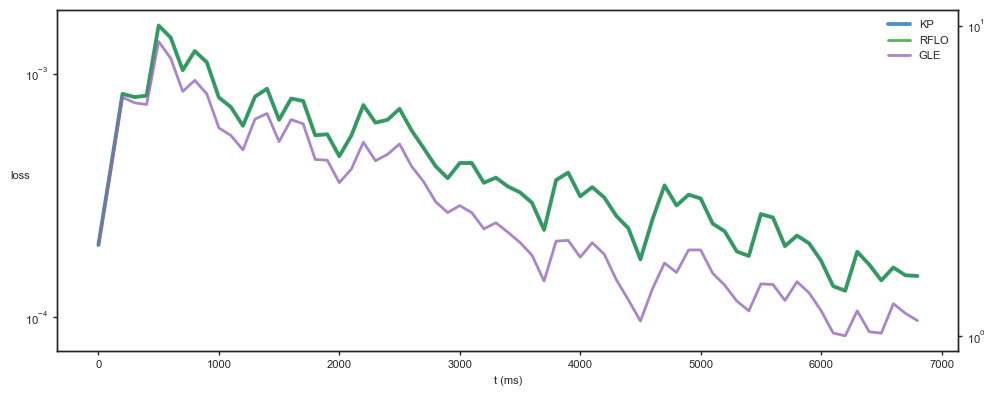

In [8]:
Error_record = np.array(error_record).T
fig = plt.figure(figsize=(10, 4))
time = np.arange(Error_record.shape[1])*100
ax = fig.add_subplot(111)
ax2 = ax.twinx()
ax.set_yscale('log')
ax.set_ylabel('loss', rotation=0)
ax2.set_yscale('log')
#ax2.set_ylabel(r"$\mathbf{u}^{ɑ}$", rotation=0)
l1,  = ax.plot(time, Error_record[0], label="KP", color=blue, linewidth=2.8, alpha=0.8)
l11, = ax.plot(time, Error_record[1], label="RFLO", color=green, linewidth=2., alpha=0.8)
l12, = ax.plot(time, Error_record[2], label="GLE", color=purple, linewidth=2., alpha=0.8)
lines = [l1, l11, l12]
labels = [line.get_label() for line in lines]
ax.legend(lines, labels, loc='upper right', frameon=False)
ax.set_xlabel('t (ms)')

plt.tight_layout()
#plt.savefig('./fig/losscurvecompare2L.png')
plt.show()

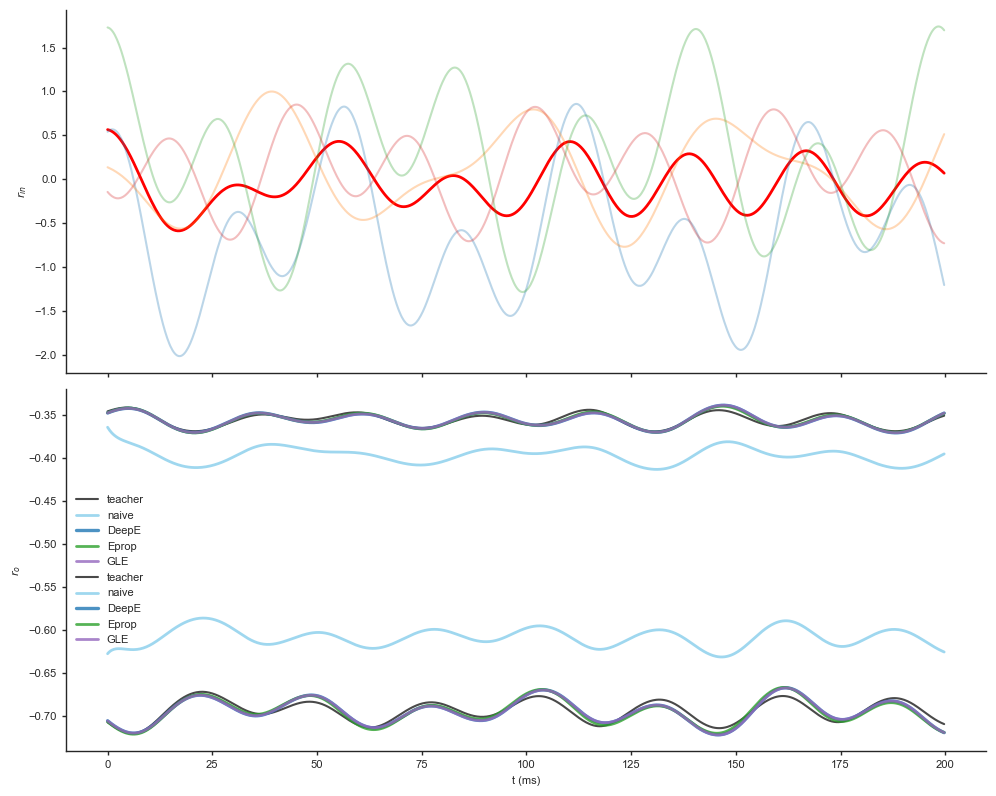

In [31]:
Rcd_eval = Recorder(['input', 'teacher', 'DeepElig', 'Eprop', 'GLE', 'naive'])
Students['naive'].align(student)
with torch.no_grad():
    for t in range(eval_phase_steps):
        t = t+init_phase_steps+learn_phase_steps
        inp = input_fuc(t)[None,:]
        Rcd_eval.rec_single('input', inp)
        r_out_target, u_out_target = teacher.step(inp)
        Rcd_eval.rec_single('teacher', u_out_target)
        for k, stu in Students.items():
            r_out, u_out = stu.step(inp)
            Rcd_eval.rec_single(k, u_out)

Rcd_eval.finish()

fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
x = np.arange(0, eval_phase, dt)
axs[0].plot(x, Rcd_eval['input'].mean(axis=0), color='r', linewidth=2)
for i in range(n_in):
    axs[0].plot(x, Rcd_eval['input'][i][0:], alpha = 0.3)
for i in range(n_out):
    axs[1].plot(x, Rcd_eval['teacher'][i][0:], label="teacher", color = black, linewidth=1.5, alpha=0.8)
    axs[1].plot(x, Rcd_eval['naive'][i][0:], label="naive", color = lightblue, linewidth=2, alpha=0.8)
    axs[1].plot(x, Rcd_eval['DeepElig'][i][:], label="DeepE", color = blue, linewidth=2.4, alpha=0.8)
    axs[1].plot(x, Rcd_eval['Eprop'][i][:], label="Eprop", color = green, linewidth=2, alpha=0.8)
    axs[1].plot(x, Rcd_eval['GLE'][i][:], label="GLE", color = purple, linewidth=2, alpha=0.8)
axs[1].legend()
axs[1].set_xlabel("t (ms)")

axs[0].set_ylabel(r"$r_{in}$")
axs[1].set_ylabel(r"$r_o$")

for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
#plt.savefig('./fig/CompareAft2L.png')
plt.show()

## N-Sum

reach steady state with error: 0.235576


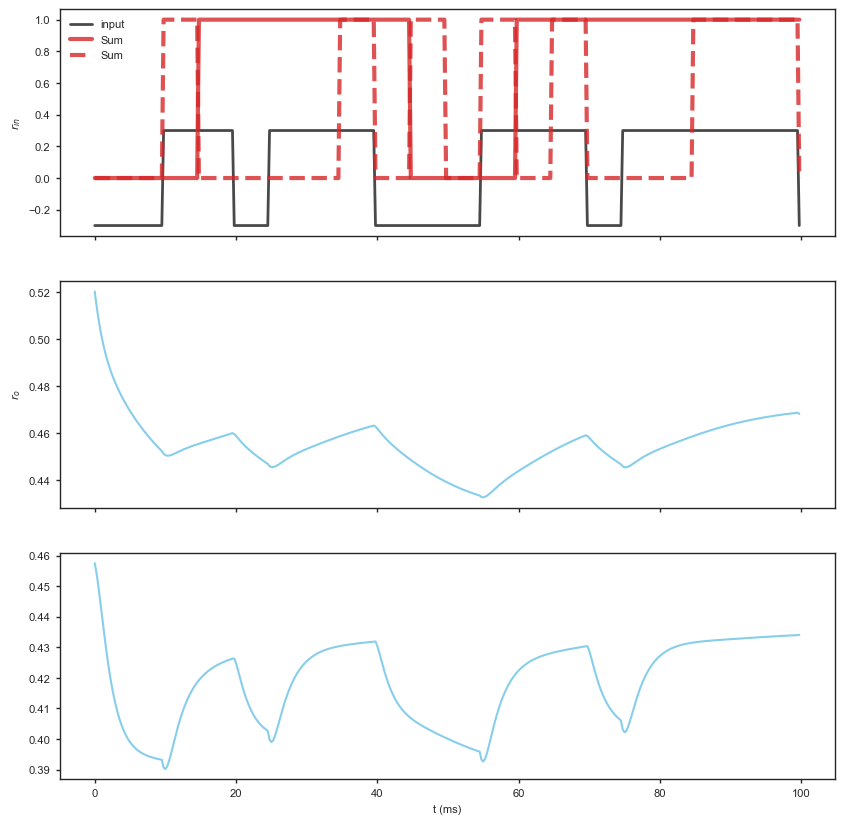

In [14]:
#### With P learning ###
dt = 0.25 #ms

init_phase = 100 #ms
init_phase_steps = int(init_phase/dt) 
learn_phase = 100000 # ms
learn_phase_steps = int(learn_phase/dt) 
eval_phase = 50 # ms
eval_phase_steps = int(eval_phase/dt)

# init both teacher and student net
N, bit_time = 3, 5

n_in, n_hidden1, n_hidden2, n_hidden3, n_out = 1, 6, 6, 6, 2
beta=torch.tensor([0.2, 1.])
tau3 = [2., 2, 4., 4., 10., 10.]


beta=torch.tensor([0.2, 1.]) * 2
decay = 0.97

student = DEFwdNetwork(
    layers=torch.nn.ModuleList([
        FwdDENeurons(n_in=n_in, n_neurons=n_hidden1, tau = dt*np.logspace(0, 1.4, n_hidden1, dtype=np.float32), lr_w=0.1,
                     activation='tanh', dt=dt, scale=1.0),
        FwdDENeuronsV2(n_in=n_hidden1, n_neurons=n_hidden2, tau = [dt, dt, 3, 3, 6, 6], lr_w=0.1,
                     activation='tanh', dt=dt, scale=0.6),
        LastFwdDENeurons(n_in=n_hidden2, n_neurons=n_hidden3, tau = tau3, lr_w=0.1,
                     activation='tanh', dt=dt, scale=1.0),
        FwdNeurons(n_in=n_hidden3, n_neurons=n_out, tau = dt, 
                   lr_w=0.1, activation='sigmoid', dt=dt, scale=1.)
    ]),
    beta=beta
)


student2 = FwdNetwork(net=student, layers=FwdRFNeurons) #learndepth
student3 = FwdNetwork(net=student, layers=FwdGLENeurons)
student4 = RTRLNetwork(net=student)
student5 = UORONetwork(net= student, n_LP = 3)
for l in student3.layers:
    l.lr_w *= 0.4

student_naive = copy.deepcopy(student2)

Students={'KP':student, 'RF':student2, 'GLE':student3, 'RTRL':student4, 'UORO':student5,'naive':student_naive}

input_fuc = StepSumBi(N=N, bit_time=bit_time, dt=dt)

#recorders
Rcd = Recorder(['input', 'teacher', 'student'])

for stu in Students.values():
    stu.reset()

with torch.no_grad():
   
    for t in range(init_phase_steps):
        inp, label = input_fuc()
        inp = inp[None,:]
        r_out, u_out = student.step(inp)
        r_out, u_out = student2.step(inp)
        r_out, u_out = student3.step(inp)
        r_out, u_out = student4.step(inp)
        Rcd.rec([inp, label, r_out])
        
    error = label - r_out
    print("reach steady state with error: %f"%(error**2).mean().item())

Rcd.finish()

fig, axs = plt.subplots(n_out+1, 1, figsize=(10, 10), sharex=True)
x = np.arange(0, init_phase, dt)
axs[0].plot(x, Rcd['input'].mean(axis=0)*0.6, color=black, label='input', linewidth=2, alpha=0.8)
axs[0].plot(x, Rcd['teacher'][0], label="Sum", color = red, alpha=0.8, linewidth=3)
axs[0].plot(x, Rcd['teacher'][1], label="Sum", color = red, alpha=0.8, linewidth=3, linestyle='--')
for i in range(n_out):
    axs[i+1].plot(x, Rcd['student'][i], label="student %d"%i, color = lightblue)


axs[-1].set_xlabel("t (ms)")
axs[0].set_ylabel(r"$r_{in}$")
axs[0].legend()
axs[1].set_ylabel(r"$r_o$")

plt.show()

In [15]:
Cum_errors = np.array(5*[(error**2).mean().item()])
error_record, mismatch_record = [], []
cum_eps = 0
Rcd = Recorder(['input','rhod'])
learn_stu = ['KP', 'RF', 'GLE', 'RTRL', 'UORO']

with torch.no_grad():
    for t in range(learn_phase_steps):
        t += init_phase_steps
        inp, label = input_fuc()
        inp = inp[None,:]
        update = (t%200 == 199)
        Grads_rec = []
        for i, stu in enumerate(learn_stu):
            r_out, u_out = Students[stu].step(inp)
            if t % (4*bit_time)>4:
                error = label - r_out
                Students[stu].prop(error)
                Students[stu].learnW(update=update)
                Cum_errors[i] = 0.9998*Cum_errors[i] + 0.0002*(error**2).mean().item()
            else:
                Students[stu].prop(learn=False)

        # Rcd.rec([input, student.mismatch(0), student.mismatch(-1), student.epsilon(1), 
        #          student.layers[0].rho.d, student3.mismatch(0)])

        if (t*dt)%800==0:
            error_record.append(list(Cum_errors))
            beta *= decay
            for i, stu in enumerate(learn_stu):
                Students[stu].layers[-1].beta = beta
            
            print(" error: %5e, t: %d ms"%(Cum_errors[0], t*dt))

Rcd.finish()

 error: 2.598992e-01, t: 800 ms
 error: 2.625058e-01, t: 1600 ms
 error: 2.291858e-01, t: 2400 ms
 error: 2.112646e-01, t: 3200 ms
 error: 1.971693e-01, t: 4000 ms
 error: 1.741085e-01, t: 4800 ms
 error: 1.604785e-01, t: 5600 ms
 error: 1.512592e-01, t: 6400 ms
 error: 1.507622e-01, t: 7200 ms
 error: 1.463810e-01, t: 8000 ms
 error: 1.392528e-01, t: 8800 ms
 error: 1.286102e-01, t: 9600 ms
 error: 1.193353e-01, t: 10400 ms
 error: 1.103455e-01, t: 11200 ms
 error: 1.027466e-01, t: 12000 ms
 error: 9.396652e-02, t: 12800 ms
 error: 9.346116e-02, t: 13600 ms
 error: 8.406638e-02, t: 14400 ms
 error: 8.086724e-02, t: 15200 ms
 error: 7.767061e-02, t: 16000 ms
 error: 8.937634e-02, t: 16800 ms
 error: 7.990563e-02, t: 17600 ms
 error: 7.064517e-02, t: 18400 ms
 error: 6.554344e-02, t: 19200 ms
 error: 5.802243e-02, t: 20000 ms
 error: 5.626784e-02, t: 20800 ms
 error: 4.839391e-02, t: 21600 ms
 error: 4.484261e-02, t: 22400 ms
 error: 4.036481e-02, t: 23200 ms
 error: 4.046318e-02, t: 24

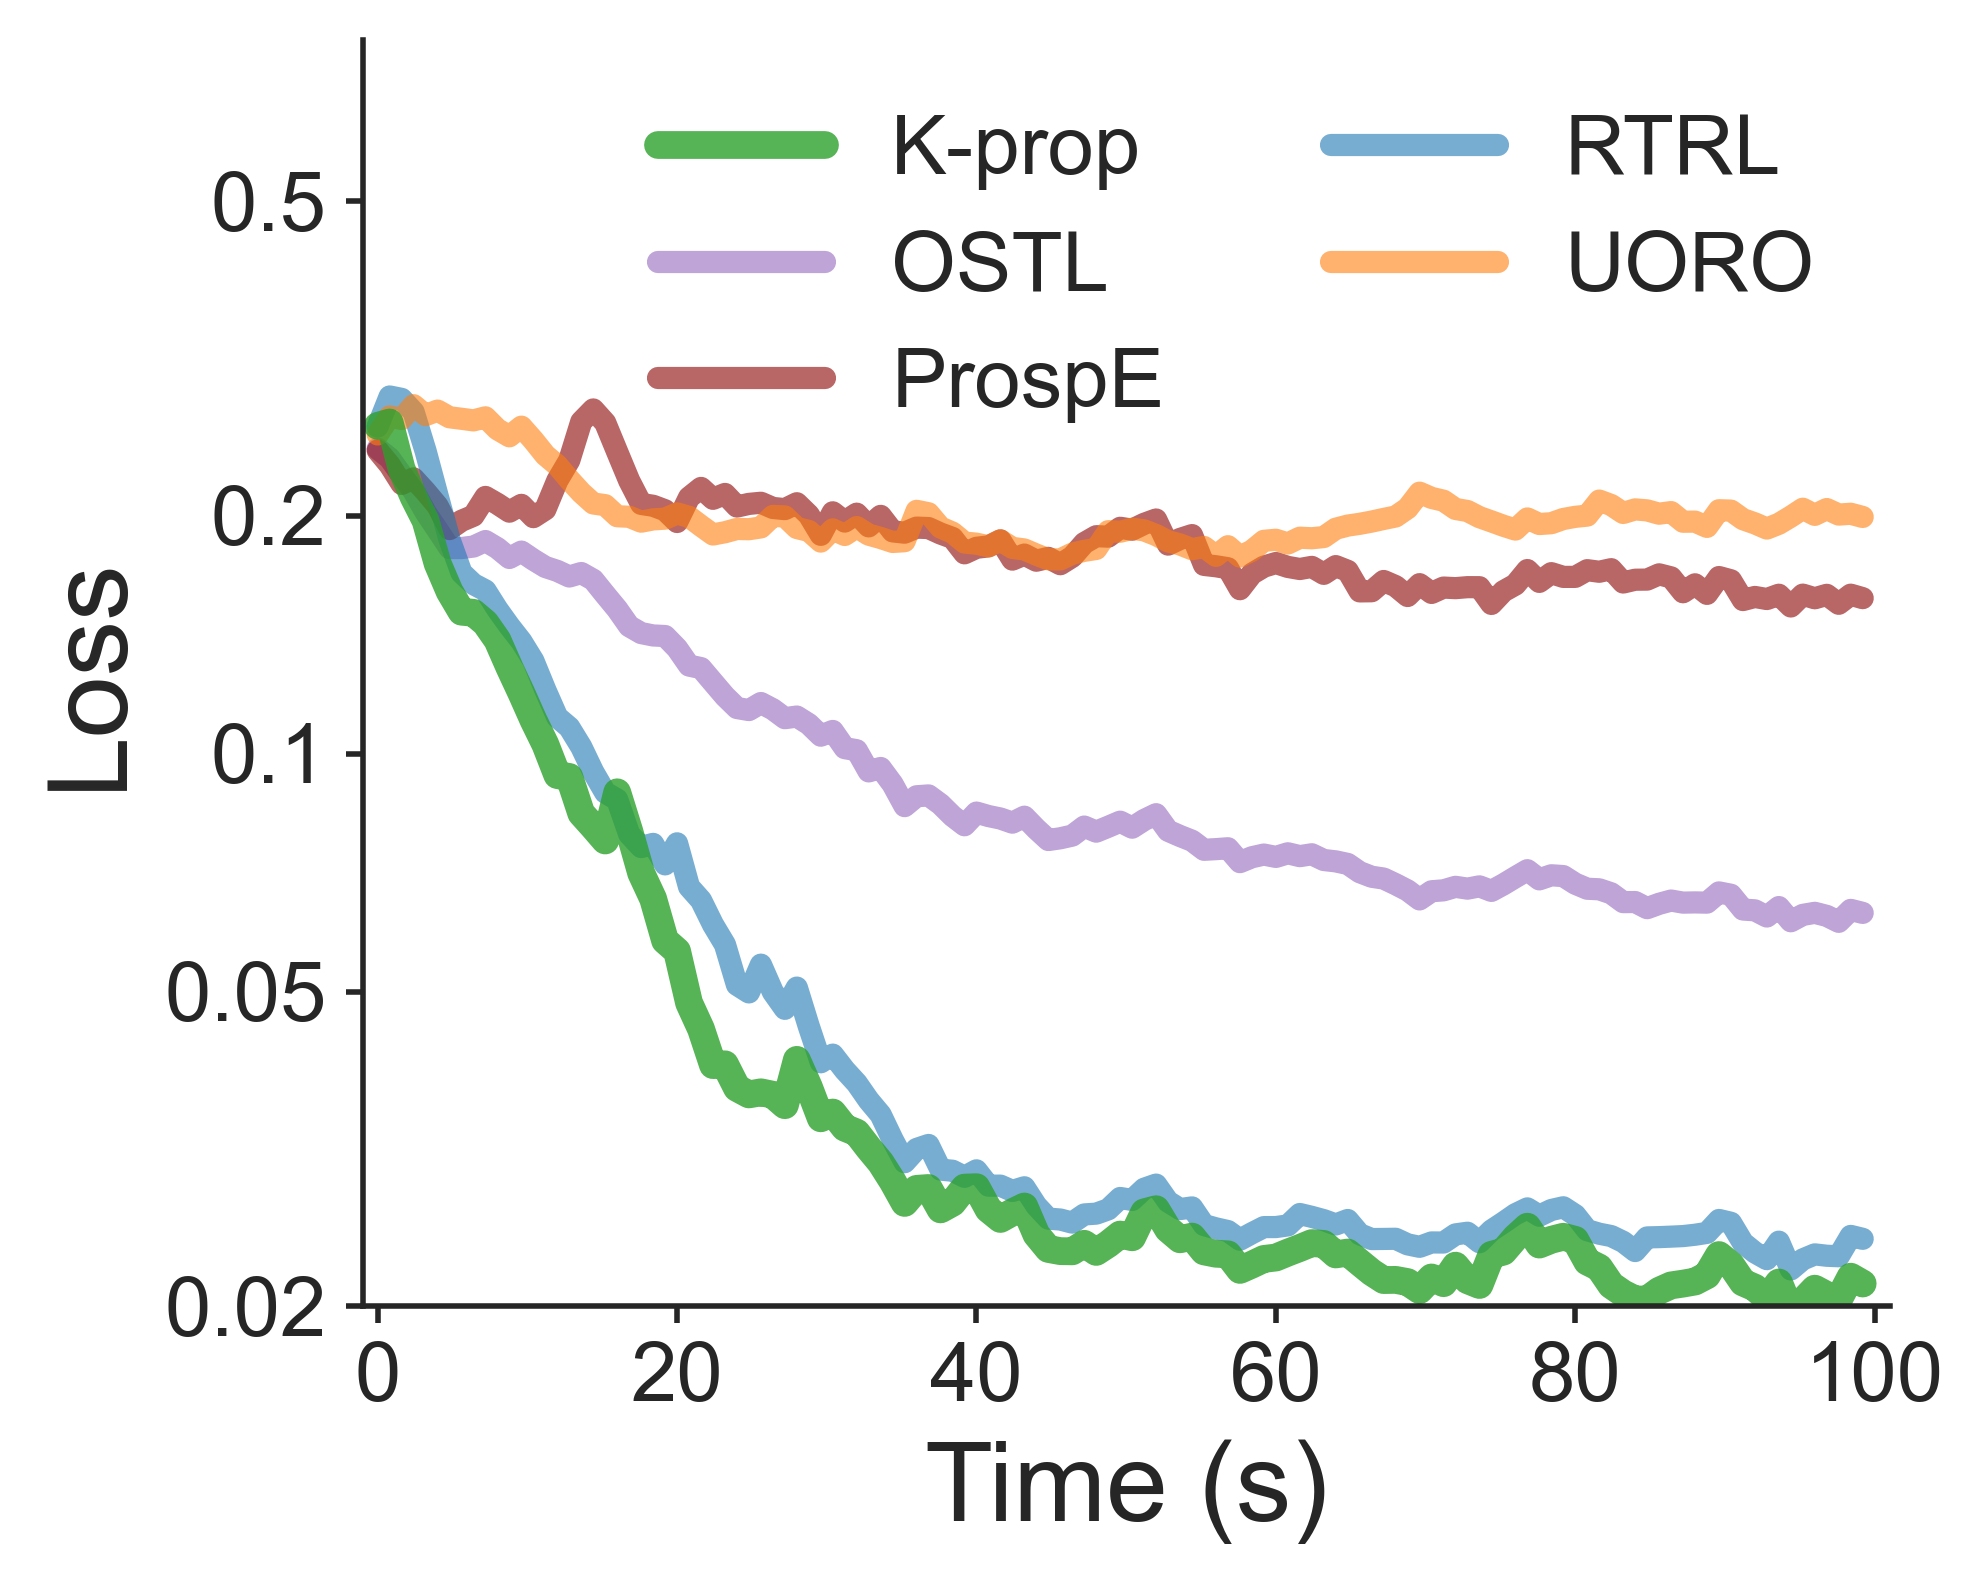

In [16]:
Error_record = np.array(error_record).T
fig = plt.figure(figsize=(5, 4), dpi=400)
time = np.arange(Error_record.shape[1])*800
ax = fig.add_subplot(111)

ax.set_yscale('log')
ax.set_ylabel('Loss', fontsize = 20)

l11, = ax.plot(time, Error_record[1], label="OSTL", color=purple, linewidth=4, alpha=0.6)
l12, = ax.plot(time, Error_record[2], label="ProspE", color=darkred, linewidth=4, alpha=0.6)
l13, = ax.plot(time, Error_record[3], label="RTRL", color=blue, linewidth=4, alpha=0.6)
l14, = ax.plot(time, Error_record[4], label="UORO", color=orange, linewidth=4, alpha=0.6)
l1,  = ax.plot(time, Error_record[0], label="K-prop", color=green, linewidth=5, alpha=0.8)
lines = [l1, l11, l12, l13, l14]
labels = [line.get_label() for line in lines]
ax.legend(lines, labels, frameon=False, fontsize = 15, ncol=2)
ax.set_xlabel('Time (s)', fontsize = 20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
#np.arange(learn_phase)
ax.set_xticks(np.arange(0, learn_phase+1, 20000), np.arange(0, int(learn_phase/1000+1), 20))
ax.set_xlim(-1000, 101000)
ax.set_yticks([0.02, 0.05, 0.1, 0.2, 0.5], [0.02, 0.05, 0.10, 0.2, 0.5])
ax.set_ylim(0.02, 0.8)
ax.tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout()
#plt.savefig('../Figures/N_sum_loss.png')
plt.show()

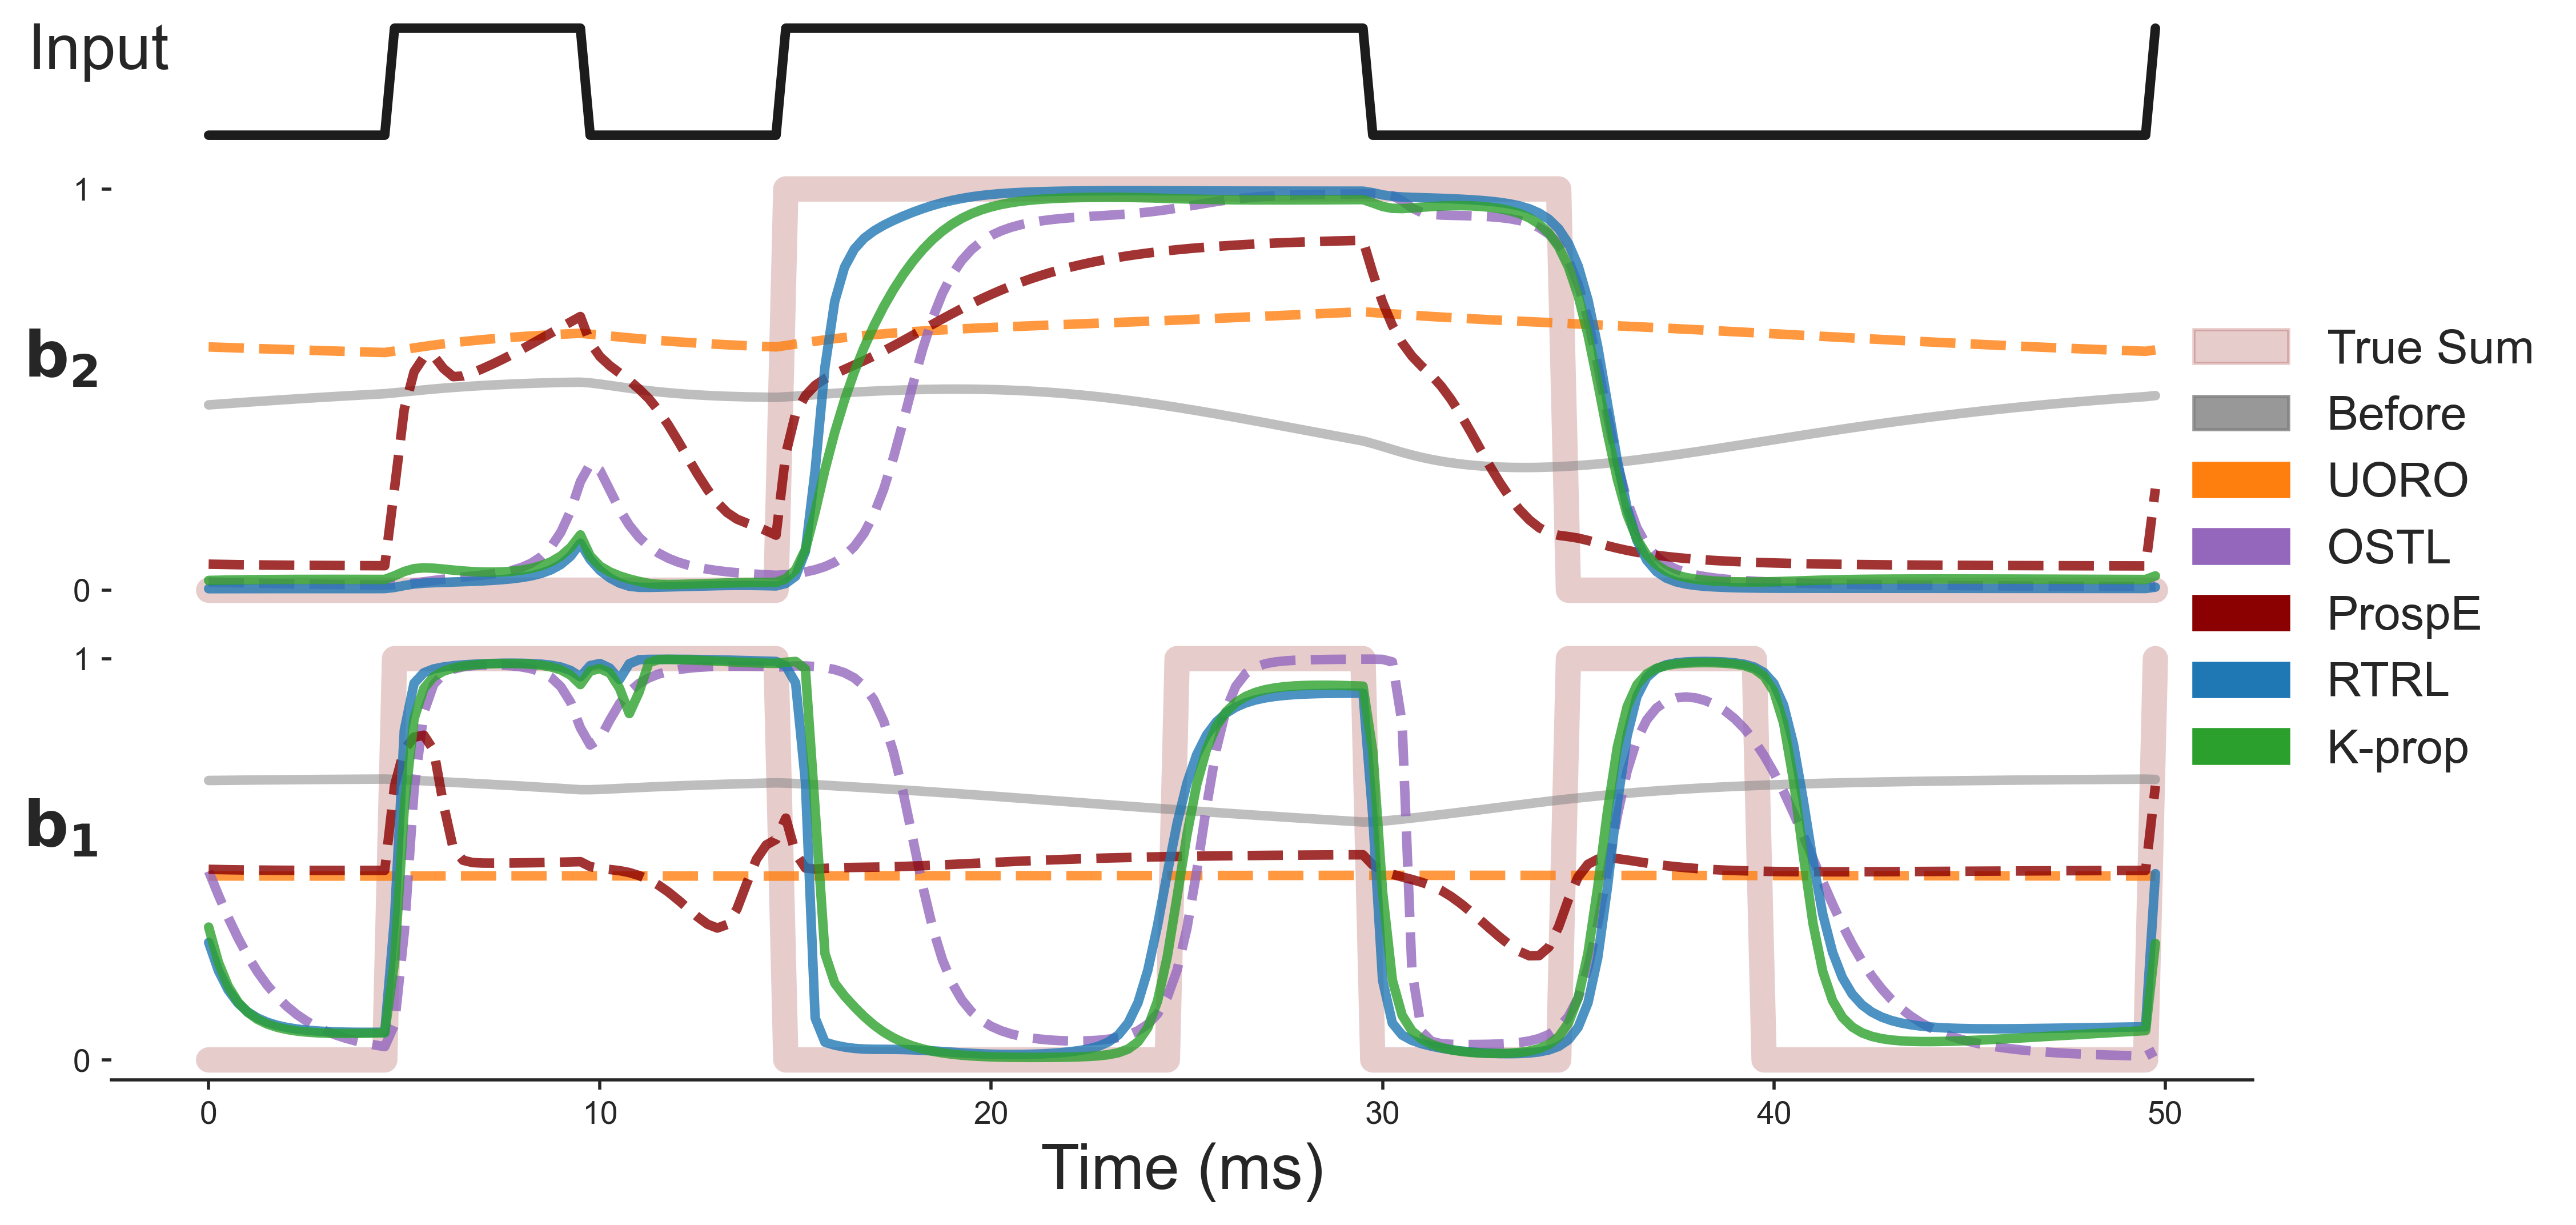

In [56]:
Rcd_eval = Recorder(['input', 'teacher', 'KP', 'RF', 'GLE', 'naive', 'RTRL', 'UORO'])

with torch.no_grad():
    for t in range(eval_phase_steps):
        t = t+init_phase_steps+learn_phase_steps
        inp, label = input_fuc()
        inp = inp[None,:]
        Rcd_eval.rec_single('input', inp)
        Rcd_eval.rec_single('teacher', label)
        for k, stu in Students.items():
            r_out, u_out = stu.step(inp)
            Rcd_eval.rec_single(k, r_out)

Rcd_eval.finish()

fig, axs = plt.subplots(n_out+1, 1, figsize=(10, 5.4), gridspec_kw={'height_ratios': [0.8, 3, 3]}, dpi=400)
x = np.arange(0, eval_phase, dt)
axs[0].plot(x, Rcd_eval['input'].mean(axis=0), color=black, linewidth=3, alpha=1.)

for i in range(n_out):
    axs[i+1].plot(x, Rcd_eval['teacher'][i], label="True Sum", color=darkred, alpha=0.2, linewidth=8)
    axs[i+1].plot(x, Rcd_eval['naive'][i][:], label="Before", color=gray, linewidth=3, alpha = 0.5)
    axs[i+1].plot(x, Rcd_eval['UORO'][i][:], color = orange, label="UORO", linewidth=3, alpha=0.8, linestyle='--')
    axs[i+1].plot(x, Rcd_eval['RF'][i][:], color = purple, label="OSTL", linewidth=3, alpha=0.8, linestyle='--')
    axs[i+1].plot(x, Rcd_eval['GLE'][i][:], color = darkred, label="ProspE", linewidth=3, alpha=0.8, linestyle='--')
    axs[i+1].plot(x, Rcd_eval['RTRL'][i][:], color = blue, label="RTRL", linewidth=3, alpha=0.8)
    axs[i+1].plot(x, Rcd_eval['KP'][i][:], color = green , label="KP (ours)", linewidth=3, alpha=0.8)
    
    
axs[-1].set_xlabel("Time (ms)", fontsize = 20)

axs[0].set_ylabel("Input", rotation=0, fontsize = 20)
axs[1].set_ylabel(r"$\mathbf{b_2}$", rotation=0, fontsize = 20)
axs[2].set_ylabel(r"$\mathbf{b_1}$", rotation=0, fontsize = 20)

for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
#axs[0].spines['left'].set_visible(False)
axs[0].spines['bottom'].set_visible(False)
axs[1].spines['bottom'].set_visible(False)
axs[0].set_yticks([])
axs[0].set_xticks([])
axs[1].set_yticks([0, 1])
axs[2].set_yticks([0, 1])
axs[1].set_xticks([])
axs[1].tick_params(axis='both', which='major', labelsize=10)
axs[2].tick_params(axis='both', which='major', labelsize=10)

handles = [
    plt.Rectangle((0, 0), 0.5, 0.5, color=darkred, alpha=0.2, label="True Sum"),
    plt.Rectangle((0, 0), 0.5, 0.5, color=gray, label='Before', alpha=0.8),
    plt.Rectangle((0, 0), 0.5, 0.5, color=orange, label='UORO'),
    plt.Rectangle((0, 0), 0.5, 0.5, color=purple, label='OSTL'),
    plt.Rectangle((0, 0), 0.5, 0.5, color=darkred, label='ProspE'),
    plt.Rectangle((0, 0), 0.5, 0.5, color=blue, label='RTRL'),
    plt.Rectangle((0, 0), 0.5, 0.5, color=green, label='K-prop'),
]
# Legend inside plot box
#axs[1].legend(handles=handles, loc='best', frameon=False, fontsize=12)
fig.legend(handles=handles, loc='center right', frameon=False, fontsize=15, bbox_to_anchor=(1.13, 0.55))

plt.tight_layout()
#plt.savefig('../Figures/N_sum_after.png', bbox_inches='tight')
plt.show()

### visualize Kernel

In [17]:
def extract_kernel(model, n_steps, layer_idx):
    model.reset()
    impulse = torch.zeros(1, 1).to(model.device) + 0.5
    rest = torch.zeros(1, 1).to(model.device)
    before = torch.zeros(1, 1).to(model.device) - 0.5

    def layer_response(inp):
        r = inp
        for l in model.layers[:layer_idx]:
            r,u = l.step(r)
        return r.detach().clone(), u.detach().clone()

    kernel_record = []
    # Achieve rest state
    for t in range(160):
        r, u = layer_response(before)
        if t > 140:
            kernel_record.append(u)

    #r, u = layer_response(impulse)
    #kernel_record = [u]
    for t in range(n_steps):
        r,u = layer_response(impulse)
        kernel_record.append(u)

    return torch.vstack(kernel_record).cpu().numpy().T

In [18]:
visual_duration = 2*bit_time*N
visual_n_steps = int(visual_duration/dt)
kernel_record_post = extract_kernel(
    student,
    n_steps=visual_n_steps,
    layer_idx=3
)

kernel_record_pre = extract_kernel(
    student_naive,
    n_steps=visual_n_steps,
    layer_idx=3
)

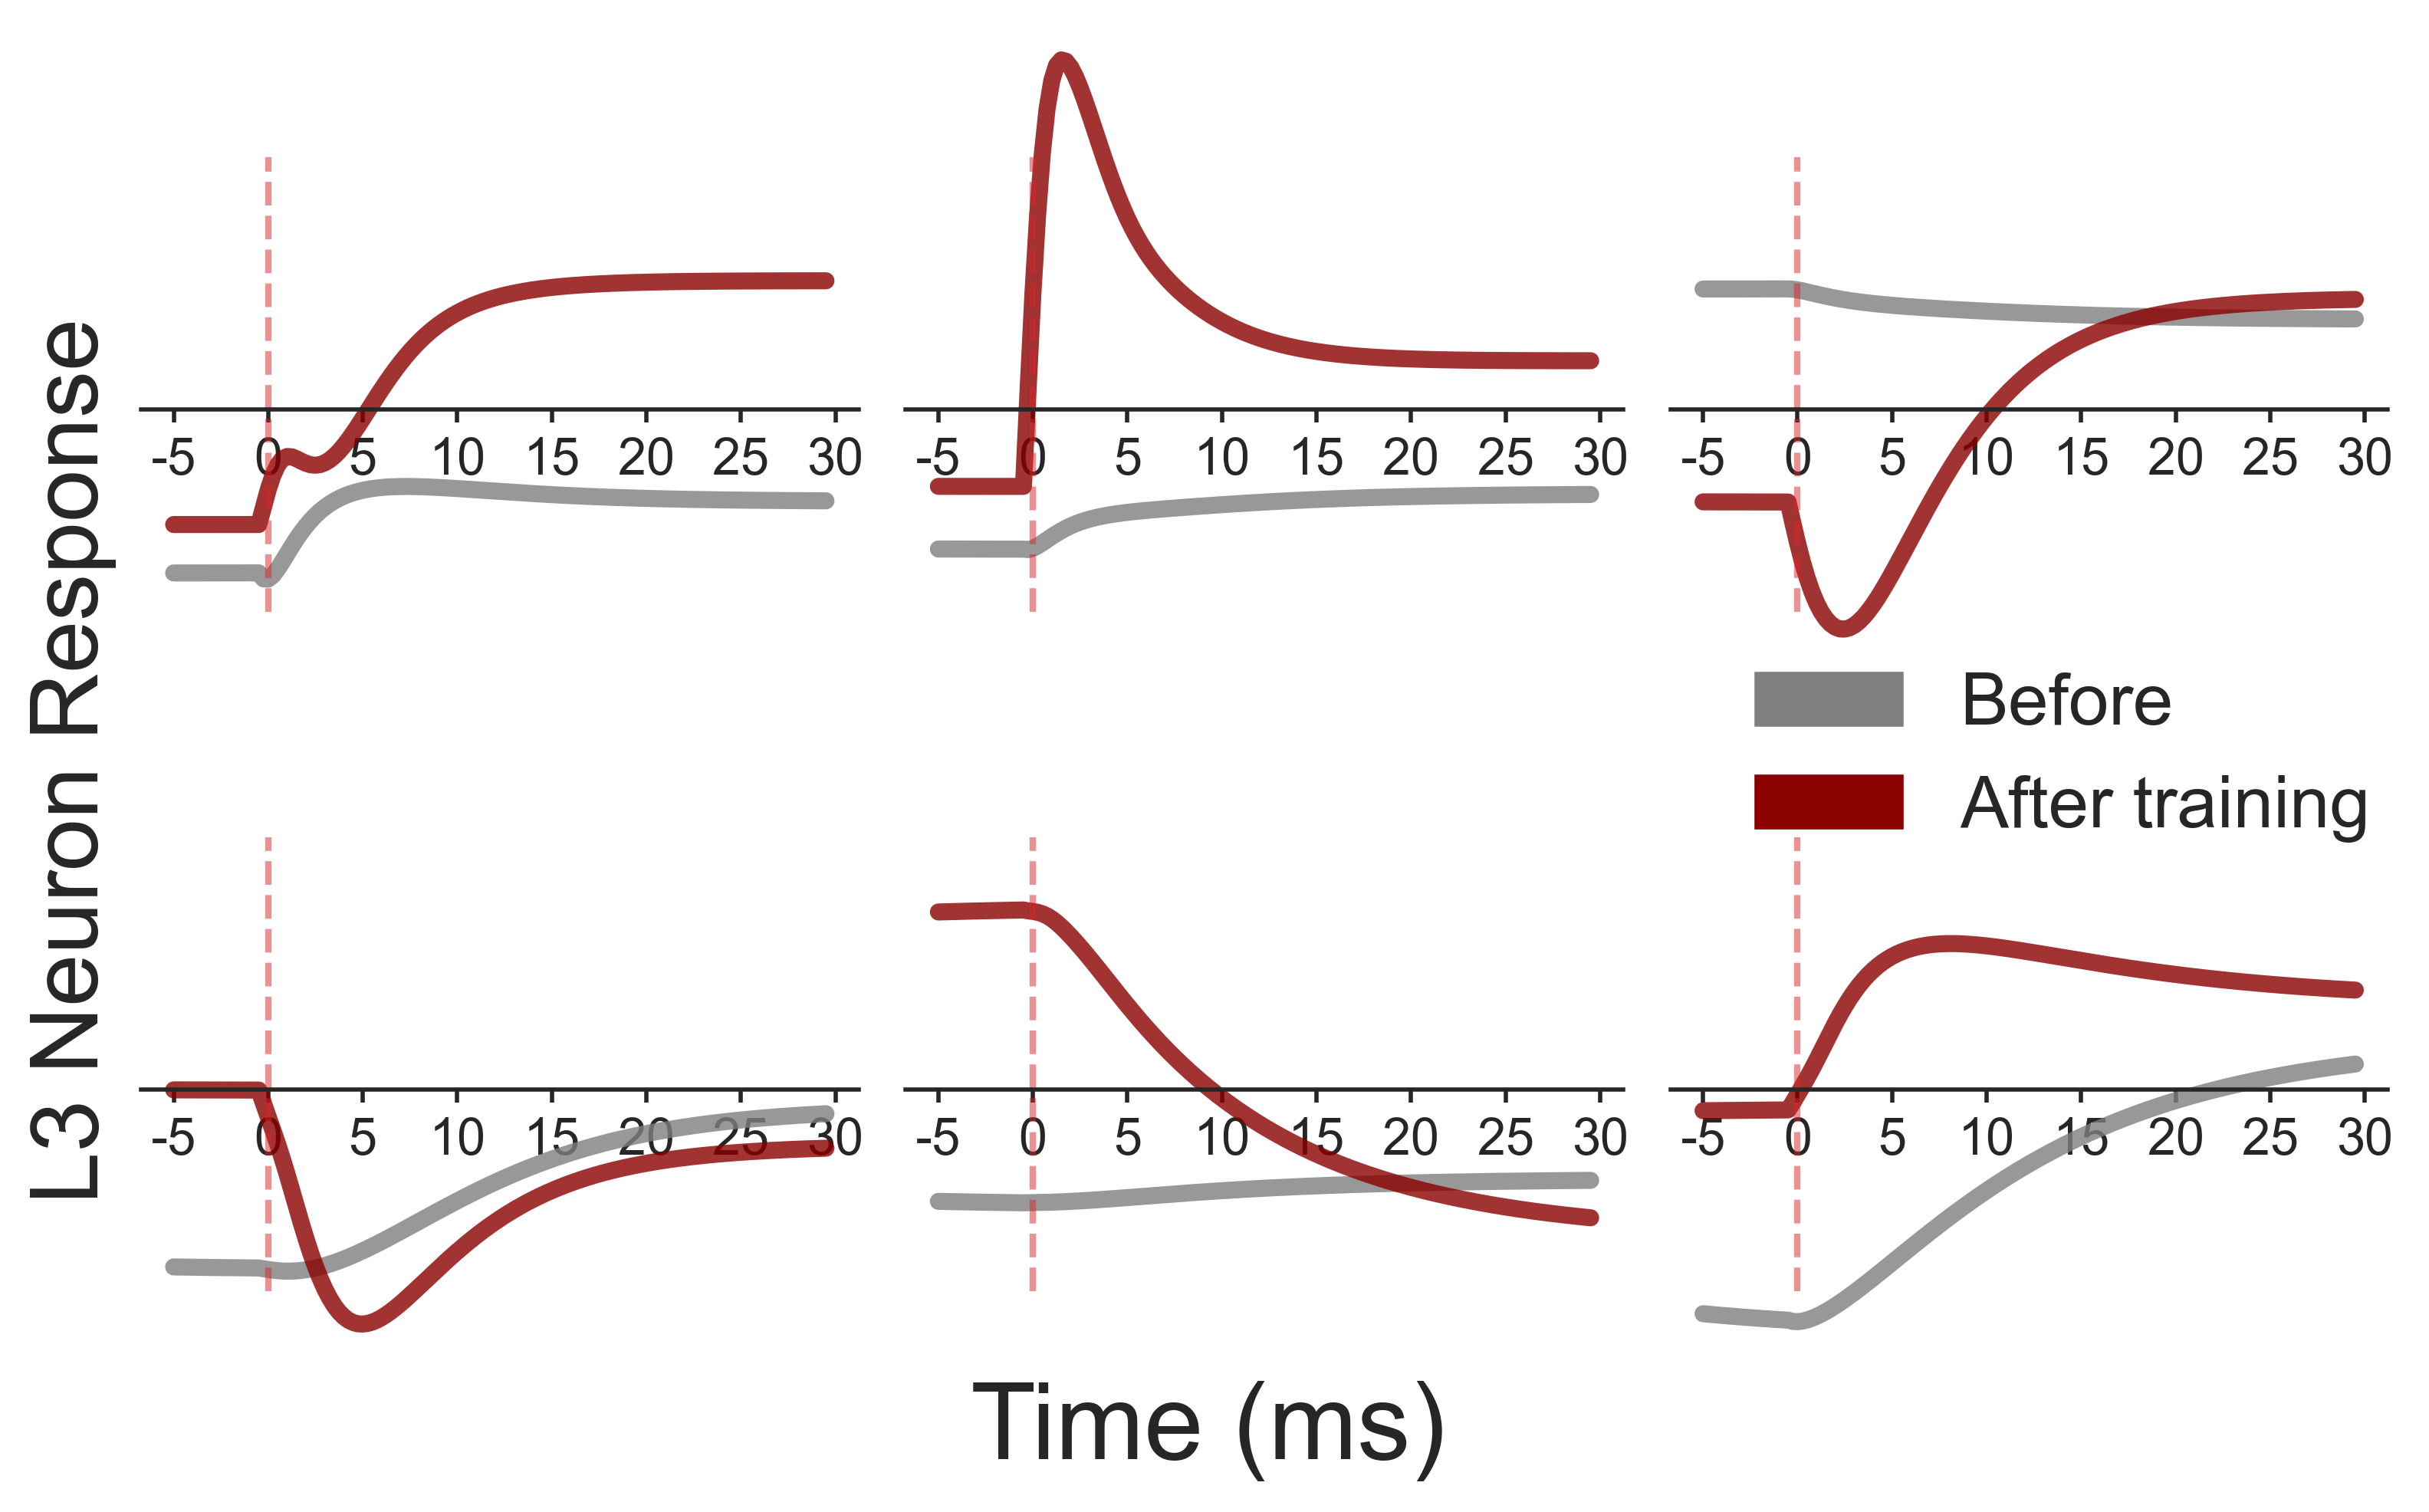

In [26]:
kernel_record_pre_norm = kernel_record_pre / np.abs(kernel_record_pre).mean(axis=1)[:, None]
kernel_record_post_norm = kernel_record_post / np.abs(kernel_record_post).mean(axis=1)[:, None]
fig, axs = plt.subplots(2, 3, figsize=(8, 5), sharey=True, dpi=400)
for i, ax in enumerate(axs.ravel()):
    ax.plot(kernel_record_pre_norm[i], label='Before training', linewidth=4, color=gray, alpha = 0.8)
    ax.plot(kernel_record_post_norm[i], label='After training', linewidth=4, color = darkred, alpha = 0.8)
    ax.set_xticks(np.arange(0, visual_n_steps+1+20, int(5/dt)), np.arange(0, visual_duration+1+5, 5)-5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_position('zero')
    #if i not in [0, 3]:
    ax.spines['left'].set_visible(False)
    ax.set_yticks([])
    ax.vlines(x = 20, ymin=-2, ymax=2.5, color=red, linestyle='--', alpha=0.5)
    ax.tick_params(axis='both', which='major', labelsize=12)

fig.supxlabel('Time (ms)', fontsize=25, y=0.03)
fig.supylabel('L3 Neuron Response', fontsize=22)
handles = [
    plt.Rectangle((0, 0), 0.5, 0.5, color=gray, label='Before'),
    plt.Rectangle((0, 0), 0.5, 0.5, color=darkred, label="After training"),
]
fig.legend(handles=handles, fontsize=17, bbox_to_anchor=(1., 0.6))
#axs.ravel()[5].legend(fontsize=15, loc="upper left")
plt.tight_layout()
plt.plot()
plt.savefig('../Figures/AcquiredResponse.png')
plt.show()

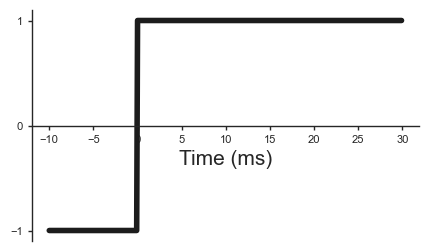

In [47]:
x = np.zeros(400)
x[:100] = -1
x[100:] = 1
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(np.arange(-10, 30, 0.1), x, color=black, linewidth=4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_position('zero')
ax.set_yticks([-1, 0, 1])
ax.set_xlabel('Time (ms)', fontsize=15)
plt.savefig('../Figures/StepInp.png')

## N-back with changing N

Multiple N?
VGG encoded cifar10?

tensor([ 3.0000,  6.0000,  2.5000,  8.5000, 16.5000,  2.0000,  8.0000, 16.0000])
reach steady state with error: 0.093189


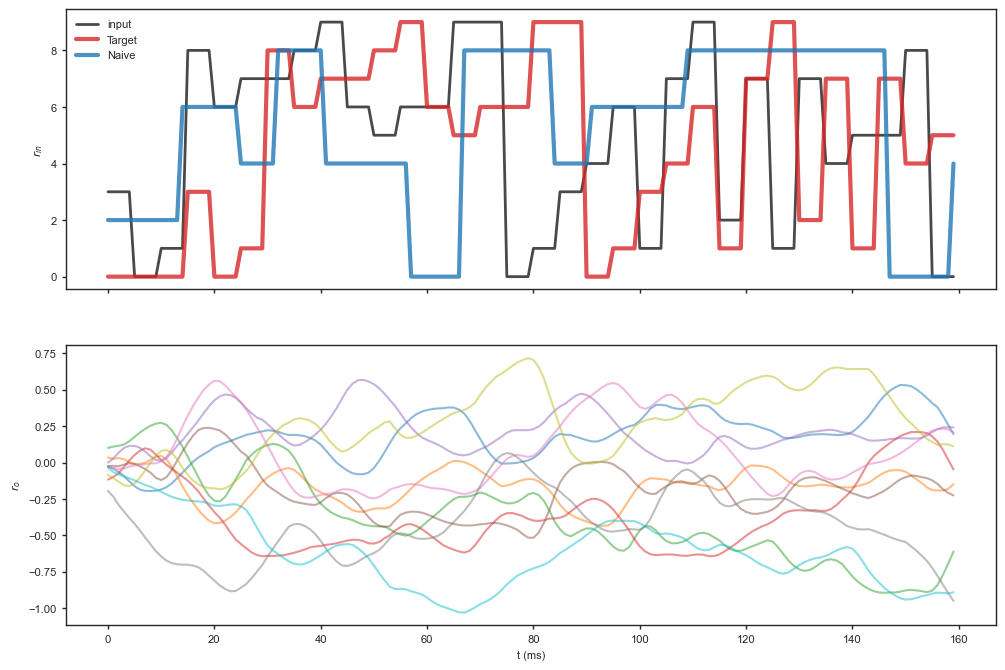

In [17]:
#### With P learning ###
dt = 1. #ms

init_phase = 160 #ms
init_phase_steps = int(init_phase/dt) 
learn_phase = 80000 # ms
learn_phase_steps = int(learn_phase/dt) 
eval_phase = 100 # ms
eval_phase_steps = int(eval_phase/dt)

# init both teacher and student net
N, n_class, max_N, show_time = 3, 10, 20, 5.

n_in, n_hidden1, n_hidden2, n_hidden3, n_out = n_class, 48, 48, 90, n_class
beta=torch.tensor(4e-2)
activation='tanh'

tau1 = np.array([2, 8, 16])
tau2 = np.array([3, 6])
tau0 = dt*np.logspace(0, 1., n_hidden1, dtype=np.float32)
tau1 = np.repeat(tau1[:, None], n_hidden2//tau1.shape[0])
tau2 = np.repeat(tau2[:, None], n_hidden3//tau2.shape[0])

student = DEFwdNetwork(
    layers=torch.nn.ModuleList([
        FwdDENeurons(n_in=n_in, n_neurons=n_hidden1, tau=tau0, lr_w=1.,
                     activation=activation, dt=dt, scale=1.),
        FwdDENeurons(n_in=n_hidden1, n_neurons=n_hidden2, tau=tau1, lr_w=1.,
                     activation=activation, dt=dt, scale=0.8),
        FwdDENeurons(n_in=n_hidden2, n_neurons=n_hidden2, tau=tau1+0.5, lr_w=1.,
                     activation=activation, dt=dt, scale=0.8),
        LastFwdDENeurons(n_in=n_hidden2, n_neurons=n_hidden3, tau=tau2, lr_w=1.,
                     activation='relu', dt=dt, scale=1.),
        FwdNeurons(n_in=n_hidden3, n_neurons=n_out, tau = dt, 
                   lr_w=0.5, activation='linear', dt=dt, scale=1.)
    ]),
    beta=beta
)


student2 = FwdNetwork(net=student, layers=FwdRFNeurons)

student3 = FwdNetwork(net=student, layers=FwdGLENeurons)

Students={'DeepElig':student, 'Eprop':student2, 'GLE':student3}

input_fuc = NBack(N=N, n_class=n_class, show_time=show_time, dt=dt, max_N=max_N)

#recorders
Rcd = Recorder(['input', 'teacher', 'student'])

student.reset()
student2.reset()
student3.reset()

with torch.no_grad():
    
    for t in range(init_phase_steps):
        inp, label = input_fuc()
        one_hot_label = F.one_hot(label, num_classes=n_class)
        inp = inp[None,:]
        r_out, u_out = student.step(inp)
        Rcd.rec([inp.argmax(), label, r_out])
        
    error = one_hot_label - torch.softmax(r_out, dim=1)
    print("reach steady state with error: %f"%(error**2).mean().item())

Rcd.finish()

fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
x = np.arange(0, init_phase, dt)
axs[0].plot(x, Rcd['input'].mean(axis=0), color=black, label='input', linewidth=2, alpha=0.8)
axs[0].plot(x, Rcd['teacher'][0], label="Target", color = red, alpha=0.8, linewidth=3)
axs[0].plot(x, Rcd['student'].argmax(axis=0), label="Naive", color = blue, alpha=0.8, linewidth=3)
for i in range(n_out):
    axs[1].plot(x, Rcd['student'][i], label="student %d"%i, alpha = 0.5)


axs[-1].set_xlabel("t (ms)")
axs[0].set_ylabel(r"$r_{in}$")
axs[0].legend()
axs[1].set_ylabel(r"$r_o$")

plt.show()

In [18]:
Cum_errors = np.array(3*[(error**2).mean().item()])
error_record, mismatch_record = [], []
cum_eps = 0
Students['Eprop'].align(student)
Students['GLE'].align(student)
Rcd = Recorder(['input','rhod'])
decay = torch.tensor(0.9)

with torch.no_grad():
    for t in range(learn_phase_steps):
        t += init_phase_steps
        inp, label = input_fuc()
        one_hot_label = F.one_hot(label, num_classes=n_class)
        inp = inp[None,:]
        update = True if t%40==0 else False
        
        for i, stu in enumerate(['DeepElig', 'Eprop', 'GLE']):
            r_out, u_out = Students[stu].step(inp)
            error = one_hot_label - torch.softmax(r_out, dim=1)
            Students[stu].prop(error)
            Students[stu].learnW(update=update)
            Cum_errors[i] = 0.999*Cum_errors[i] + 0.001*(error**2).mean().item()

        # if t==50000:
        #     input_fuc.change_N(3)
        #     beta=torch.tensor(2e-3)
        #     Cum_errors[0]=0.09

        if (t*dt)%2000==0:
            error_record.append(list(Cum_errors))
            beta *= decay
            for i, stu in enumerate(['DeepElig', 'Eprop', 'GLE']):
                Students[stu].beta = beta
            
            print(" error: %5e, t: %d ms"%(Cum_errors[0], t*dt))

Rcd.finish()

 error: 8.918631e-02, t: 2000 ms
 error: 8.524322e-02, t: 4000 ms
 error: 7.882006e-02, t: 6000 ms
 error: 7.692383e-02, t: 8000 ms
 error: 7.442885e-02, t: 10000 ms
 error: 7.157898e-02, t: 12000 ms
 error: 7.092889e-02, t: 14000 ms
 error: 6.928672e-02, t: 16000 ms
 error: 6.708349e-02, t: 18000 ms
 error: 6.760073e-02, t: 20000 ms
 error: 6.488797e-02, t: 22000 ms
 error: 6.556032e-02, t: 24000 ms
 error: 6.365603e-02, t: 26000 ms
 error: 6.284584e-02, t: 28000 ms
 error: 6.066088e-02, t: 30000 ms
 error: 5.856300e-02, t: 32000 ms
 error: 5.779182e-02, t: 34000 ms
 error: 5.619741e-02, t: 36000 ms
 error: 5.745432e-02, t: 38000 ms
 error: 5.637087e-02, t: 40000 ms
 error: 5.690206e-02, t: 42000 ms
 error: 5.709409e-02, t: 44000 ms
 error: 5.539760e-02, t: 46000 ms
 error: 5.555401e-02, t: 48000 ms
 error: 5.534883e-02, t: 50000 ms
 error: 5.351891e-02, t: 52000 ms
 error: 5.518756e-02, t: 54000 ms
 error: 5.363371e-02, t: 56000 ms
 error: 5.316540e-02, t: 58000 ms
 error: 5.266303e-

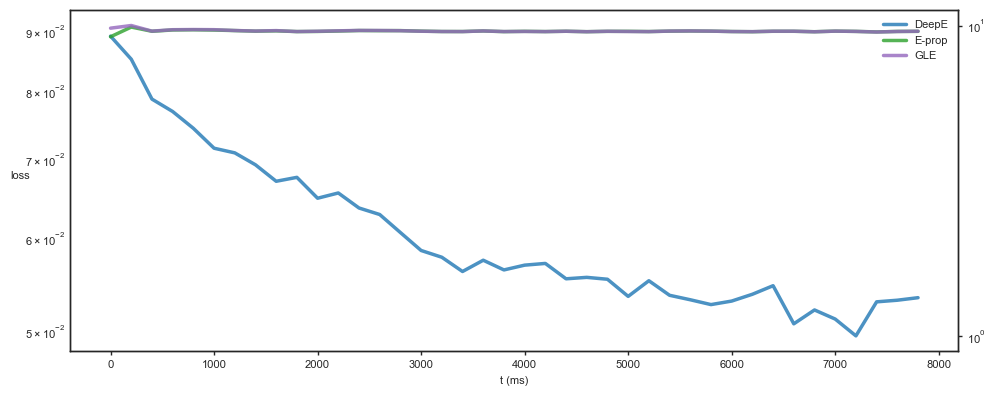

In [19]:
Error_record = np.array(error_record).T
fig = plt.figure(figsize=(10, 4))
time = np.arange(Error_record.shape[1])*200
ax = fig.add_subplot(111)
ax2 = ax.twinx()
ax.set_yscale('log')
ax.set_ylabel('loss', rotation=0)
ax2.set_yscale('log')
#ax2.set_ylabel(r"$\mathbf{u}^{ɑ}$", rotation=0)
l1,  = ax.plot(time, Error_record[0], label="DeepE", color=blue, linewidth=2.5, alpha=0.8)
l11, = ax.plot(time, Error_record[1], label="E-prop", color=green, linewidth=2.5, alpha=0.8)
l12, = ax.plot(time, Error_record[2], label="GLE", color=purple, linewidth=2.5, alpha=0.8)
lines = [l1, l11, l12]
labels = [line.get_label() for line in lines]
ax.legend(lines, labels, loc='upper right', frameon=False)
ax.set_xlabel('t (ms)')

plt.tight_layout()
#plt.savefig('./fig/losscurvecompare2L.png')
plt.show()

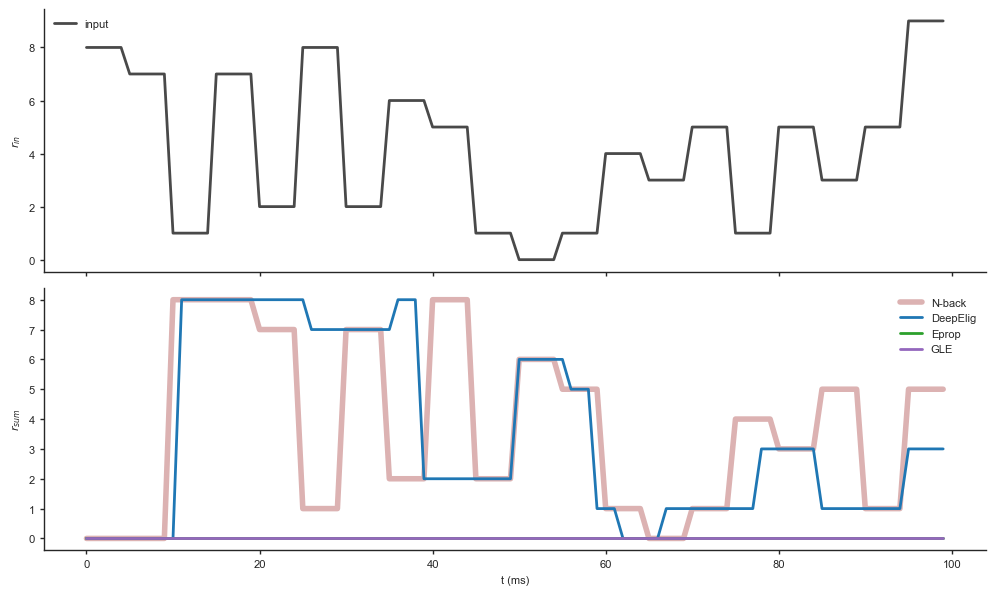

In [20]:
Rcd_eval = Recorder(['input', 'teacher', 'DeepElig', 'Eprop', 'GLE'])

#Students['naive'].align(student)
with torch.no_grad():
    for t in range(eval_phase_steps):
        t = t+init_phase_steps+learn_phase_steps
        inp, label = input_fuc()
        inp = inp[None,:]
        Rcd_eval.rec_single('input', inp.argmax())
        Rcd_eval.rec_single('teacher', label)
        for k, stu in Students.items():
            r_out, u_out = stu.step(inp)
            Rcd_eval.rec_single(k, r_out.argmax())

Rcd_eval.finish()



fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
x = np.arange(0, eval_phase, dt)
axs[0].plot(x, Rcd_eval['input'].mean(axis=0), color=black, label='input', linewidth=2, alpha=0.8)

axs[1].plot(x, Rcd_eval['teacher'][0], label="N-back", color=darkred, alpha=0.3, linewidth=4)
axs[1].plot(x, Rcd_eval['DeepElig'][0,:], label="DeepElig", color = blue, linewidth=2)
axs[1].plot(x, Rcd_eval['Eprop'][0,:], label="Eprop", color = green, linewidth=2)
axs[1].plot(x, Rcd_eval['GLE'][0,:], label="GLE", color = purple, linewidth=2)
    
axs[0].legend()
axs[1].legend()
axs[-1].set_xlabel("t (ms)")

axs[0].set_ylabel(r"$r_{in}$")
axs[1].set_ylabel(r"$r_{sum}$")

for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
#plt.savefig('./fig/CompareAftRec.png')
plt.show()

## N-back with Recurrent

reach steady state with error: 0.096845


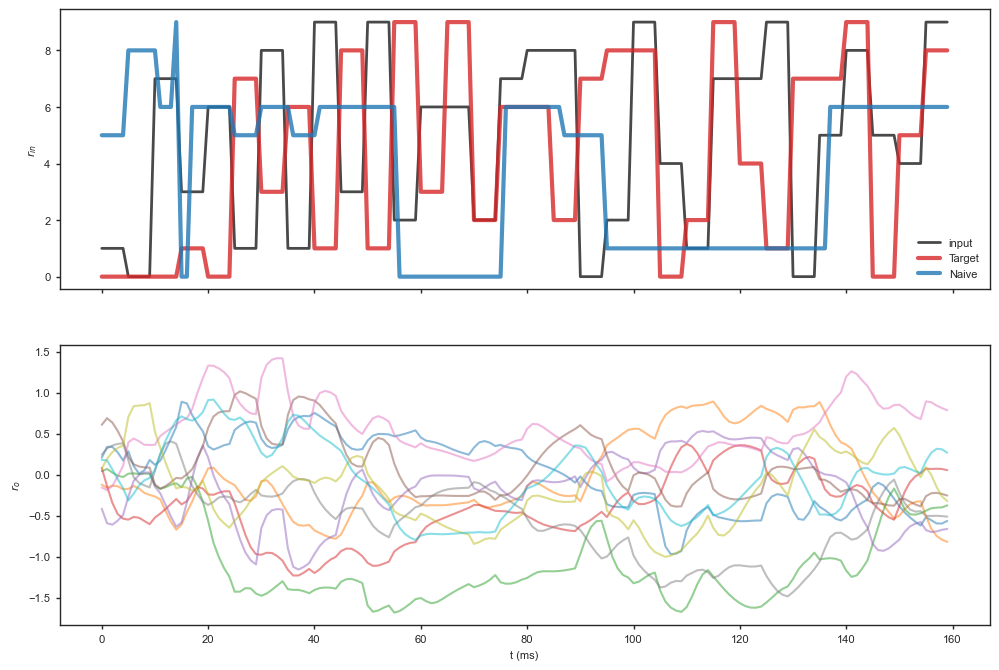

In [66]:
#### With P learning ###
dt = 1. #ms

init_phase = 160 #ms
init_phase_steps = int(init_phase/dt) 
learn_phase = 160000 # ms
learn_phase_steps = int(learn_phase/dt) 
eval_phase = 100 # ms
eval_phase_steps = int(eval_phase/dt)

# init both teacher and student net
N, n_class, max_N, show_time = 3, 10, 20, 5.

n_in, n_rec, n_hidden, n_out = n_class, 150, 50, n_class
beta=torch.tensor(1e-2)
activation='tanh'

tau = np.array([2, 8, 32])
tau = np.repeat(tau[:, None], n_rec//tau.shape[0])

student = FwdNetwork(
    layers=torch.nn.ModuleList([
        RecDENeurons(n_in=n_in, n_neurons=n_rec, tau=tau, lr_w=1.,
                     activation=activation, dt=dt),
        FwdNeurons(n_in=n_rec, n_neurons=n_hidden, tau = dt, 
                   lr_w=1., activation=activation, dt=dt),
        FwdNeurons(n_in=n_hidden, n_neurons=n_out, tau = dt, 
                   lr_w=0.5, activation='linear', dt=dt)
    ]),
    beta=beta
)


student2 = FwdNetwork(
    layers=torch.nn.ModuleList([
        RecRFNeurons(n_in=n_in, n_neurons=n_rec, tau=tau, lr_w=1.,
                     W_in=student.layers[0].W_in.detach().clone(),
                     bias=student.layers[0].bias.detach().clone(),
                     activation=activation, dt=dt),
        FwdNeurons(n_in=n_rec, n_neurons=n_hidden, tau = dt,
                   W_in=student.layers[1].W_in.detach().clone(),
                   bias=student.layers[1].bias.detach().clone(),
                   lr_w=1., activation=activation, dt=dt),
        FwdNeurons(n_in=n_hidden, n_neurons=n_out, tau = dt, 
                   W_in=student.layers[-1].W_in.detach().clone(),
                   bias=student.layers[-1].bias.detach().clone(),
                   lr_w=0.5, activation='linear', dt=dt)
    ]),
    beta=beta
)

# optimizer = torch.optim.Adam(
#         model.parameters(),
#         lr=train_config["learning_rate"],
#         betas=(0.9, 0.999)
#     )

# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer,
#     mode='min',
#     factor=0.75,
#     patience=2
# )

Students={'DeepElig':student, 'RFLO':student2}

input_fuc = NBack(N=N, n_class=n_class, show_time=show_time, dt=dt, max_N=max_N)

#recorders
Rcd = Recorder(['input', 'teacher', 'student'])

student.reset()
student2.reset()

with torch.no_grad():
    
    for t in range(init_phase_steps):
        inp, label = input_fuc()
        one_hot_label = F.one_hot(label, num_classes=n_class)
        inp = inp[None,:]
        r_out, u_out = student.step(inp)
        student.prop(learn=False)
        r_out, u_out = student2.step(inp)
        student2.prop(learn=False)
        Rcd.rec([inp.argmax(), label, r_out])
        
    error = one_hot_label - torch.softmax(r_out, dim=1)
    print("reach steady state with error: %f"%(error**2).mean().item())

Rcd.finish()

fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
x = np.arange(0, init_phase, dt)
axs[0].plot(x, Rcd['input'].mean(axis=0), color=black, label='input', linewidth=2, alpha=0.8)
axs[0].plot(x, Rcd['teacher'][0], label="Target", color = red, alpha=0.8, linewidth=3)
axs[0].plot(x, Rcd['student'].argmax(axis=0), label="Naive", color = blue, alpha=0.8, linewidth=3)
for i in range(n_out):
    axs[1].plot(x, Rcd['student'][i], label="student %d"%i, alpha = 0.5)


axs[-1].set_xlabel("t (ms)")
axs[0].set_ylabel(r"$r_{in}$")
axs[0].legend()
axs[1].set_ylabel(r"$r_o$")

plt.show()

In [67]:
Cum_errors = np.array(3*[(error**2).mean().item()])
error_record, mismatch_record = [], []
Rcd = Recorder(['input','rhod'])
decay = torch.tensor(0.9)

with torch.no_grad():
    for t in range(learn_phase_steps):
        t += init_phase_steps
        inp, label = input_fuc()
        one_hot_label = F.one_hot(label, num_classes=n_class)
        inp = inp[None,:]
        update = True if t%50==0 else False
        
        for i, stu in enumerate(Students.values()):
            r_out, u_out = stu.step(inp)
            error = one_hot_label - torch.softmax(r_out, dim=1)
            stu.prop(error)
            stu.learnW(update=update)
            Cum_errors[i] = 0.999*Cum_errors[i] + 0.001*(error**2).mean().item()

        # Rcd.rec([input, student.mismatch(0), student.mismatch(-1), student.epsilon(1), 
        #          student.layers[0].rho.d, student3.mismatch(0)])
        # if t==50000:
        #     input_fuc.change_N(3)
        #     beta=torch.tensor(1e-3)
        #     Cum_errors[0]=0.09
        
        if (t*dt)%5000==0:
            error_record.append(list(Cum_errors))
            beta *= decay
            for stu in Students.values():
                stu.beta = beta
            print(" error: %.4e, t: %d ms"%(Cum_errors[0], t*dt))

Rcd.finish()

 error: 8.8567e-02, t: 5000 ms
 error: 8.4025e-02, t: 10000 ms
 error: 8.2371e-02, t: 15000 ms
 error: 7.8677e-02, t: 20000 ms
 error: 7.4714e-02, t: 25000 ms
 error: 7.3993e-02, t: 30000 ms
 error: 7.3697e-02, t: 35000 ms
 error: 7.0089e-02, t: 40000 ms
 error: 6.6318e-02, t: 45000 ms
 error: 6.3602e-02, t: 50000 ms
 error: 6.6435e-02, t: 55000 ms
 error: 6.4905e-02, t: 60000 ms
 error: 6.3813e-02, t: 65000 ms
 error: 6.6507e-02, t: 70000 ms
 error: 6.1526e-02, t: 75000 ms
 error: 6.3450e-02, t: 80000 ms
 error: 6.1673e-02, t: 85000 ms
 error: 6.1655e-02, t: 90000 ms
 error: 5.9872e-02, t: 95000 ms
 error: 5.8868e-02, t: 100000 ms
 error: 5.6659e-02, t: 105000 ms
 error: 5.6400e-02, t: 110000 ms
 error: 5.8327e-02, t: 115000 ms
 error: 5.2533e-02, t: 120000 ms
 error: 5.5475e-02, t: 125000 ms
 error: 5.1235e-02, t: 130000 ms
 error: 5.4392e-02, t: 135000 ms
 error: 5.3551e-02, t: 140000 ms
 error: 5.4767e-02, t: 145000 ms
 error: 5.6664e-02, t: 150000 ms
 error: 5.5350e-02, t: 155000 

In [68]:
student.layers[0].W[:, 10:].max()

tensor(0.7108, grad_fn=<MaxBackward1>)

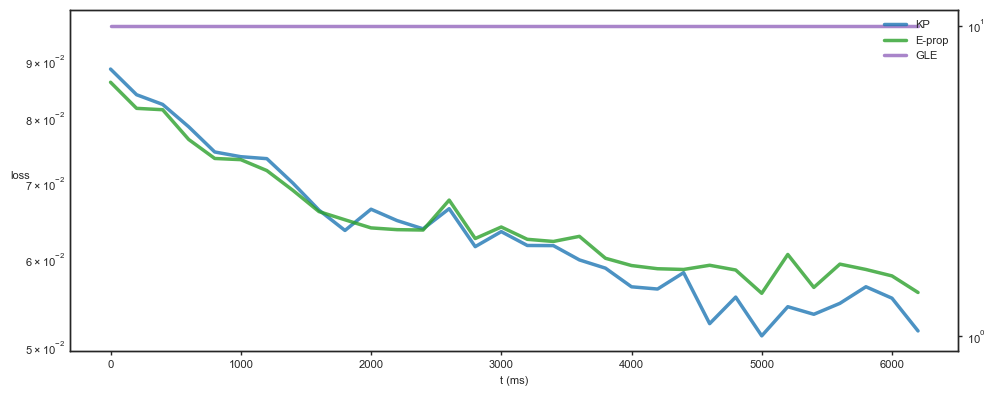

In [69]:
Error_record = np.array(error_record).T
fig = plt.figure(figsize=(10, 4))
time = np.arange(Error_record.shape[1])*200
ax = fig.add_subplot(111)
ax2 = ax.twinx()
ax.set_yscale('log')
ax.set_ylabel('loss', rotation=0)
ax2.set_yscale('log')
#ax2.set_ylabel(r"$\mathbf{u}^{ɑ}$", rotation=0)
l1,  = ax.plot(time, Error_record[0], label="KP", color=blue, linewidth=2.5, alpha=0.8)
l11, = ax.plot(time, Error_record[1], label="E-prop", color=green, linewidth=2.5, alpha=0.8)
l12, = ax.plot(time, Error_record[2], label="GLE", color=purple, linewidth=2.5, alpha=0.8)
lines = [l1, l11, l12]
labels = [line.get_label() for line in lines]
ax.legend(lines, labels, loc='upper right', frameon=False)
ax.set_xlabel('t (ms)')

plt.tight_layout()
#plt.savefig('./fig/losscurvecompare2L.png')
plt.show()

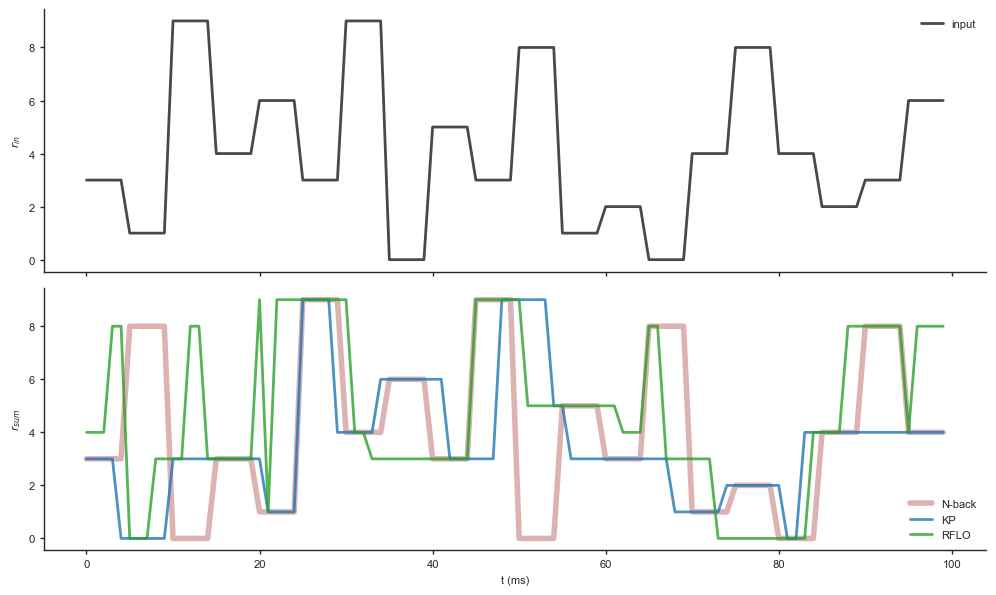

In [70]:
Rcd_eval = Recorder(['input', 'teacher', 'DeepElig', 'RFLO'])

#Students['naive'].align(student)
with torch.no_grad():
    for t in range(eval_phase_steps):
        t = t+init_phase_steps+learn_phase_steps
        inp, label = input_fuc()
        inp = inp[None,:]
        Rcd_eval.rec_single('input', inp.argmax())
        Rcd_eval.rec_single('teacher', label)
        for k, stu in Students.items():
            r_out, u_out = stu.step(inp)
            Rcd_eval.rec_single(k, r_out.argmax())

Rcd_eval.finish()



fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
x = np.arange(0, eval_phase, dt)
axs[0].plot(x, Rcd_eval['input'].mean(axis=0), color=black, label='input', linewidth=2, alpha=0.8)

axs[1].plot(x, Rcd_eval['teacher'][0], label="N-back", color=darkred, alpha=0.3, linewidth=4)
axs[1].plot(x, Rcd_eval['DeepElig'][0,:], label="KP", color = blue, linewidth=2, alpha=0.8)
axs[1].plot(x, Rcd_eval['RFLO'][0,:], label="RFLO", color = green, linewidth=2, alpha=0.8)
#axs[1].plot(x, Rcd_eval['GLE'][0,:], label="GLE", color = purple, linewidth=2)
    
axs[0].legend()
axs[1].legend()
axs[-1].set_xlabel("t (ms)")

axs[0].set_ylabel(r"$r_{in}$")
axs[1].set_ylabel(r"$r_{sum}$")

for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
#plt.savefig('./fig/CompareAftRec.png')
plt.show()